<a href="https://colab.research.google.com/github/Marcel-12345/PCVK_Ganjil_2026/blob/main/PCVKWeek3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
NAMA   : Anselmus Marcel Putra Andria
NIM    : 244107020141 | N = 141
b      : 39
a      : 1.6
c      : 31
gamma  : 1.15
bit    : 5
WAKTU  : 2026-09-18 20:43:29 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 498ecfa3a4045d57

Praktikum
Mengubah tingkat kecerahan citra
--------------------------------
Masukkan nilai kecerahan: 10


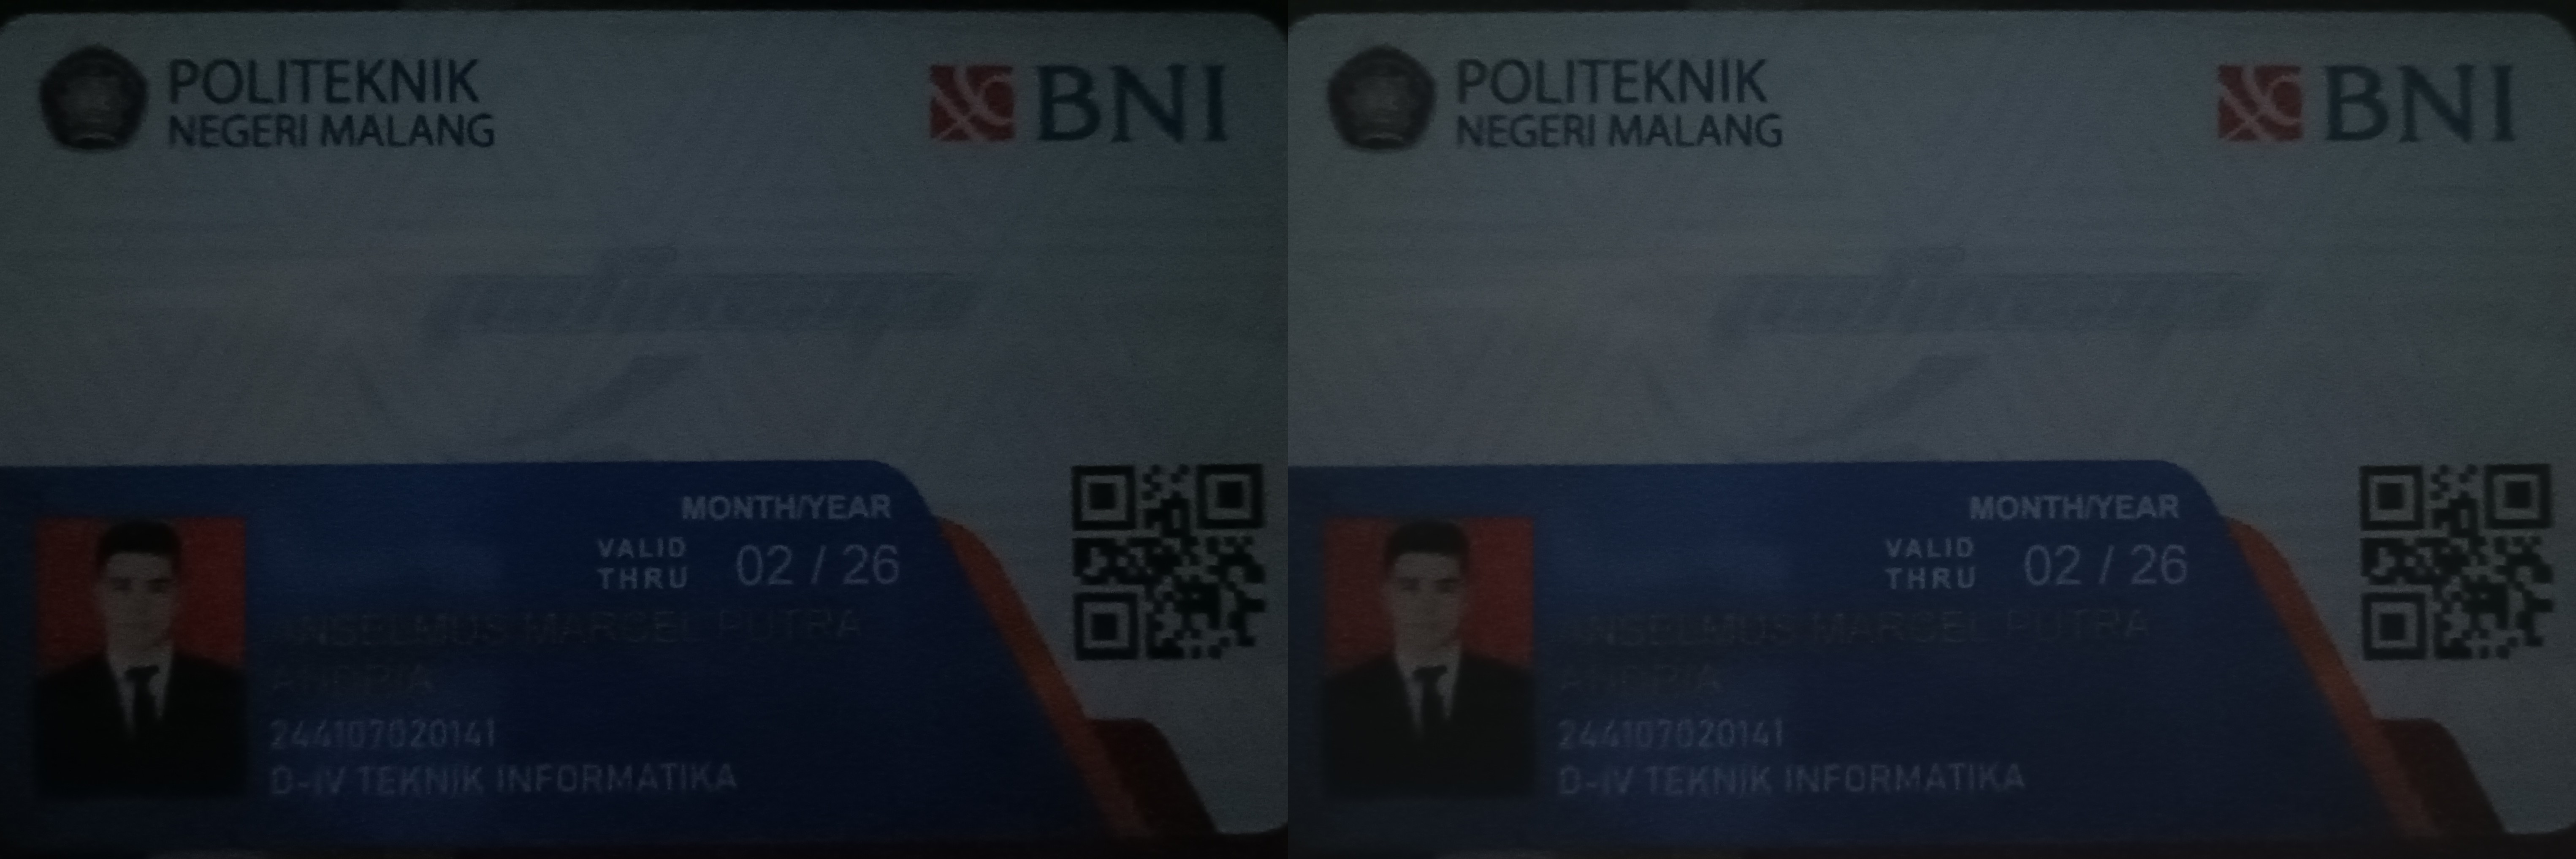

In [10]:
# IMPORT
from google.colab import drive
drive.mount("/content/drive")
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

# SEL IDENTITAS
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Anselmus Marcel Putra Andria'
NIM  = '244107020141'

N     = int(NIM[-3:])
PARAM = {
    'b'    : (N % 61) + 20,
    'a'    : round(1.0 + (N % 9) / 10, 1),
    'c'    : (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit'  : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

#PRAKTIKUM
print("")
print("Praktikum")

print('Mengubah tingkat kecerahan citra')
print('--------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020141/ktm1a.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image [y,x,c] = np.clip(original [y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)